<a href="https://colab.research.google.com/github/Kingarthuria/Project_Student_Depression/blob/main/final_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost lightgbm catboost
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install category_encoders

In [ ]:
import optuna
import optuna.visualization as vis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import category_encoders as ce
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, balanced_accuracy_score, auc
import warnings
warnings.filterwarnings("ignore")

# %matplotlib inline

In [ ]:
# ── Linear Models ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC

# ── Tree-Based ─────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)

# ── Boosting (install jika belum ada) ─────────────────────────
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

# ── Probabilistik & Lainnya ────────────────────────────────────
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [ ]:
raw = pd.read_csv('/content/student_depression_dataset.csv')
df = raw.copy()

# Preprocessing

In [ ]:
def transform(df):

    # Drop Column
    df.drop(columns=['id', 'Have you ever had suicidal thoughts ?', 'Profession', 'Job Satisfaction', 'Work Pressure'], inplace=True)

    # Gender
    df['Gender'] = df['Gender'].replace({
        'Male': 0,
        'Female': 1
    })

    # Age clipping
    df['Age'] = df['Age'].clip(upper=35)

    # CGPA
    df['CGPA'] = df['CGPA'].clip(lower=5.0)

    # Study Satisfaction
    df.loc[
        df['Study Satisfaction'] == 0.0,
        'Study Satisfaction'
    ] = df['Study Satisfaction'].mode()[0]

    # Financial Stress
    df['Financial Stress'] = (
        df['Financial Stress']
        .replace('?', np.nan)
        .astype(float)
    )
    df['Financial Stress'].fillna(
        df['Financial Stress'].mode()[0],
        inplace=True
    )

    # Academic Pressure
    df['Academic Pressure'] = (
        df['Academic Pressure']
        .replace(0.0, np.nan)
    )
    df['Academic Pressure'].fillna(
        df['Academic Pressure'].mode()[0],
        inplace=True
    )

    # Sleep Duration
    df.loc[
        df['Sleep Duration'] == 'Others',
        'Sleep Duration'
    ] = df['Sleep Duration'].mode()[0]

    sleep_map = {
        "'Less than 5 hours'": 0,
        "'5-6 hours'": 1,
        "'7-8 hours'": 2,
        "'More than 8 hours'": 3
    }
    df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)

    df['Sleep Duration'].fillna(
        df['Sleep Duration'].mode()[0],
        inplace=True
    )

    # City
    non_cities = [
        "Saanvi", "Bhavna", "Mira", "Harsha", "Vaanya", "Gaurav",
        "Harsh", "Reyansh", "Kibara", "Rashi", "Mihir",
        "Nalini", "Nandini", "M.Tech", "ME", "M.Com",
        "3.0", "City", "'Less Delhi'", "'Less than 5 Kalyan'"
    ]

    correction_map = {
        "Nalyan": "Kalyan",
        "Khaziabad": "Ghaziabad"
    }

    df["City"] = df["City"].replace(correction_map)
    df.loc[df["City"].isin(non_cities), "City"] = 'Others'

    # Dietary Habits
    df.loc[
        df['Dietary Habits'] == 'Others',
        'Dietary Habits'
    ] = df['Dietary Habits'].mode()[0]

    df['Dietary Habits'] = df['Dietary Habits'].replace({
        'Unhealthy': 0,
        'Moderate': 1,
        'Healthy': 2
    })

    # Family History of Mental Illness
    df['Family History of Mental Illness'] = df['Family History of Mental Illness'].replace({
        'No': 0,
        'Yes': 1
    })

    degree_mapping = {
      # High School
      "Class 12": "High School",
      "'Class 12'": "High School",

      # Bachelor
      "BA": "Bachelor",
      "BSc": "Bachelor",
      "BCA": "Bachelor",
      "BE": "Bachelor",
      "B.Tech": "Bachelor",
      "BBA": "Bachelor",
      "B.Com": "Bachelor",
      "B.Ed": "Bachelor",
      "B.Arch": "Bachelor",
      "BHM": "Bachelor",
      "MBBS": "Bachelor",
      "LLB": "Bachelor",
      "B.Pharm": "Bachelor",

      # Master
      "MA": "Master",
      "MSc": "Master",
      "MCA": "Master",
      "MBA": "Master",
      "M.Tech": "Master",
      "ME": "Master",
      "M.Com": "Master",
      "M.Ed": "Master",
      "MHM": "Master",
      "M.Pharm": "Master",
      "LLM": "Master",

      # Doctorate
      "PhD": "Doctorate",
      "MD": "Doctorate"
    }

    df['Education Level'] = (
        df["Degree"]
        .str.strip()
        .map(degree_mapping)
        .dropna()
    )

    # Hapus High School
    df = df[df['Education Level'] != "High School"]
    df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])

    # Encoding
    df['Education Level'] = df['Education Level'].replace({
        'Bachelor': 0,
        'Master': 1,
        'Doctorate': 2
    })

    # Pindahkan posisi kolom Education Level setelah Degree
    col_index = df.columns.get_loc('Degree')
    df.insert(col_index + 1, 'Education Level', df.pop('Education Level'))

    # Hapus kolom Degree
    df = df.drop('Degree', axis=1)

    # Numeric columns (aman)
    num_cols = [
        'Age', 'Academic Pressure',
        'Study Satisfaction',
        'Work/Study Hours', 'Financial Stress'
    ]

    for col in num_cols:
        df[col] = (
    pd.to_numeric(df[col], errors='coerce').astype('Int64'))

    return df


def clean_education_data(df):
    # Tentukan batasan usia minimum yang logis (Baseline India/Global)
    # S1 (Bachelor) ~ 17-18, S2 (Master) ~ 21-22, S3 (Doctorate) ~ 24-25
    age_limits = {
        0 : 17,
        1 : 21,
        2 : 24
    }

    print("--- Analisis Data Sebelum Pembersihan ---")
    anomalies = []

    for degree, min_age in age_limits.items():
        # Identifikasi baris yang tidak memenuhi syarat usia minimum
        bad_data = df[(df['Education Level'] == degree) & (df['Age'] < min_age)]
        if not bad_data.empty:
            print(f"Ditemukan {len(bad_data)} anomali pada gelar {degree} (Usia < {min_age})")
            anomalies.extend(bad_data.index.tolist())

    # Pembersihan
    if anomalies:
        # Menghapus baris berdasarkan index yang ditemukan
        df = df.drop(index=anomalies).reset_index(drop=True)
        print(f"\nTotal baris dihapus: {len(anomalies)}")
        print("Data berhasil dibersihkan.")
        return df
    else:
        print("\nTidak ditemukan data anomali.")
        return df

In [ ]:
print(f"Sebelum Transformasi: {df.shape[0]} Baris dan {df.shape[1]} Kolom\n")
df_clean = transform(df)
print(f"Sesudah Transformasi: {df_clean.shape[0]} Baris dan {df_clean.shape[1]} Kolom\n")
df_clean = clean_education_data(df_clean)
print(f"Sebelum Transformasi: {df_clean.shape[0]} Baris dan {df_clean.shape[1]} Kolom\n")

Sebelum Transformasi: 27901 Baris dan 18 Kolom

Sesudah Transformasi: 21821 Baris dan 13 Kolom

--- Analisis Data Sebelum Pembersihan ---
Ditemukan 24 anomali pada gelar 1 (Usia < 21)
Ditemukan 46 anomali pada gelar 2 (Usia < 24)

Total baris dihapus: 70
Data berhasil dibersihkan.
Sebelum Transformasi: 21751 Baris dan 13 Kolom



# Modeling

In [ ]:
# ══════════════════════════════════════════════════════════════
#  LOAD DATA
# ══════════════════════════════════════════════════════════════

TARGET       = "Depression"
CITY_COL     = "City"
RANDOM_STATE = 180915

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  STEP 1 — TRAIN / TEST SPLIT
#  Split DULU sebelum encoding & scaling untuk mencegah
#  data leakage dari test set ke proses training
# ══════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [ ]:
# ══════════════════════════════════════════════════════════════
#  STEP 2 — TARGET ENCODING untuk kolom City
# ══════════════════════════════════════════════════════════════

te = TargetEncoder(cols=[CITY_COL], smoothing=1)

X_train = X_train.copy()
X_test  = X_test.copy()

# Simpan mapping SEBELUM overwrite kolom
_city_encoded = te.fit_transform(X_train[[CITY_COL]], y_train)
city_target_mean = (
    X_train[[CITY_COL]]
    .assign(encoded=_city_encoded[CITY_COL].values)
    .drop_duplicates()
    .set_index(CITY_COL)["encoded"]
    .rename("target")
    .sort_values(ascending=False)
)

X_train[CITY_COL] = _city_encoded[CITY_COL]
X_test[CITY_COL]  = te.transform(X_test[[CITY_COL]])[CITY_COL]

print(f"[1] Target Encoding selesai. Contoh mapping City:")
print(city_target_mean.head(8).round(4).to_string())
print()

[1] Target Encoding selesai. Contoh mapping City:
City
Hyderabad    0.6499
Ahmedabad    0.6340
Patna        0.6105
Rajkot       0.5902
Meerut       0.5860
Bhopal       0.5719
Kalyan       0.5679
Kolkata      0.5617



In [ ]:
# ══════════════════════════════════════════════════════════════
#  STEP 3 — NORMALISASI (StandardScaler)
#  Scaler di-fit HANYA pada X_train, lalu transform keduanya
# ══════════════════════════════════════════════════════════════
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(f"[2] Normalisasi selesai.")
print(f"    Shape X_train : {X_train_scaled.shape}")
print(f"    Shape X_test  : {X_test_scaled.shape}\n")

[2] Normalisasi selesai.
    Shape X_train : (17400, 12)
    Shape X_test  : (4351, 12)



In [ ]:
# ══════════════════════════════════════════════════════════════
#  DAFTAR MODEL
#  Data sudah ternormalisasi → tidak perlu Pipeline scaler lagi
# ══════════════════════════════════════════════════════════════
models = {
    # Linear
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM":           LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    "SGD Classifier":       SGDClassifier(random_state=RANDOM_STATE),

    # Tree-Based
    "Decision Tree":        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost":             AdaBoostClassifier(random_state=RANDOM_STATE),

    # Probabilistik & Lainnya
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (k=5)":            KNeighborsClassifier(n_neighbors=5),
    "Kernel SVM (RBF)":     SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "MLP Neural Net":       MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_STATE),
    "QDA":                  QuadraticDiscriminantAnalysis(),
}

if HAS_XGB:
    models["XGBoost"]  = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
if HAS_LGB:
    models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
if HAS_CAT:
    models["CatBoost"] = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)

In [ ]:
# ══════════════════════════════════════════════════════════════
#  TRAINING & EVALUASI (tanpa leakage)
# ══════════════════════════════════════════════════════════════

is_binary  = len(np.unique(y)) == 2
avg_method = "binary" if is_binary else "weighted"

# Gunakan X_train MENTAH (sebelum encoding & scaling)
# Pipeline akan handle encoding + scaling di setiap fold secara otomatis
X_train_raw = X_train
X_test_raw  = X_test

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("te",    TargetEncoder(cols=[CITY_COL], smoothing=1)),
        ("scaler", StandardScaler()),
        ("model",  model),
    ])

    # CV sepenuhnya bersih — TargetEncoder fit ulang tiap fold
    cv_scores = cross_val_score(
        pipe, X_train_raw, y_train, cv=5, scoring="accuracy"
    )

    # Final fit pada seluruh X_train, prediksi pada X_test
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)

    try:
        y_prob = pipe.predict_proba(X_test_raw)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except (AttributeError, NotImplementedError):
        auc = np.nan

    results.append({
        "Model":              name,
        "CV Accuracy (mean)": round(cv_scores.mean(), 4),
        "CV Std":             round(cv_scores.std(),  4),
        "Test Accuracy":      round(accuracy_score(y_test, y_pred), 4),
        "Precision":          round(precision_score(y_test, y_pred, average=avg_method, zero_division=0), 4),
        "Recall":             round(recall_score(y_test, y_pred, average=avg_method, zero_division=0), 4),
        "F1-Score":           round(f1_score(y_test, y_pred, average=avg_method, zero_division=0), 4),
        "ROC-AUC":            round(auc, 4) if not np.isnan(auc) else "N/A",
    })

In [ ]:
# ══════════════════════════════════════════════════════════════
#  DATAFRAME HASIL
# ══════════════════════════════════════════════════════════════
df_results = (
    pd.DataFrame(results)
    .sort_values("Recall", ascending=False)
    .reset_index(drop=True)
)
df_results.index += 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("=" * 110)
print("                            PERBANDINGAN MODEL CLASSIFIER — TARGET: Depression")
print("=" * 110)
print(df_results.to_string())
print("=" * 110)

print("\n TOP 3 MODEL:")
print(df_results.head(5)[["Model", "Recall", "F1-Score", "ROC-AUC", "CV Accuracy (mean)", "Test Accuracy"]].to_string())

# Export opsional
# df_results.to_csv("hasil_perbandingan_model.csv", index=True)

                            PERBANDINGAN MODEL CLASSIFIER — TARGET: Depression
                   Model  CV Accuracy (mean)  CV Std  Test Accuracy  Precision  Recall  F1-Score ROC-AUC
1       Kernel SVM (RBF)              0.7859  0.0063         0.8026     0.8098  0.8360    0.8227  0.8689
2               CatBoost              0.7881  0.0093         0.8014     0.8135  0.8272    0.8203  0.8772
3    Logistic Regression              0.7909  0.0086         0.8040     0.8175  0.8268    0.8221   0.878
4             Linear SVM              0.7907  0.0087         0.8035     0.8168  0.8268    0.8218     N/A
5      Gradient Boosting              0.7905  0.0077         0.7991     0.8110  0.8259    0.8184  0.8789
6               AdaBoost              0.7913  0.0067         0.7991     0.8133  0.8221    0.8177  0.8791
7               LightGBM              0.7890  0.0078         0.7991     0.8135  0.8217    0.8176  0.8758
8            Extra Trees              0.7745  0.0071         0.7911     0.8026  0

1. 🏆 Performa Terbaik secara Keseluruhan

    Logistic Regression menempati #1 di Test Accuracy (0.8040) dan memiliki F1-Score kompetitif (0.8221) — hanya selisih 0.0006 dari Kernel SVM yang F1-nya tertinggi, perbedaan yang tidak signifikan secara praktis.

2. 📊 CV Accuracy Tertinggi dengan Std Rendah

    Logistic Regression → CV Mean: 0.7909 | CV Std: 0.0086

    Kernel SVM (RBF)    → CV Mean: 0.7859 | CV Std: 0.0063

    CV Accuracy tertinggi menunjukkan model paling konsisten saat divalidasi lintas fold, bukan hanya kebetulan bagus di satu split tertentu.

3. 📈 ROC-AUC Terbaik di Antara Top 3
ModelROC-AUCLogistic Regression0.878 ← tertinggiKernel SVM (RBF)0.8689Linear SVMN/A
ROC-AUC mengukur kemampuan diskriminasi model secara keseluruhan — lebih robust dari accuracy untuk kasus klasifikasi.

4. ⚖️ Generalisasi Baik (Gap CV vs Test Kecil)

    CV Accuracy  : 0.7909

    Test Accuracy: 0.8040

    Gap          : +0.0131  ← model tidak overfitting

    Gap positif kecil menandakan model generalisasi dengan baik ke data baru, bukan overfitting ke training data.

5. 🔍 Interpretabilitas Tinggi

    Tidak seperti SVM atau boosting, Logistic Regression menghasilkan koefisien yang bisa diinterpretasi langsung — setiap fitur punya bobot yang menjelaskan arah dan besar pengaruhnya terhadap prediksi depresi. Ini penting jika hasil model perlu dijelaskan ke stakeholder non-teknis.

6. ⚡ Efisiensi Komputasi

    Logistic Regression jauh lebih ringan dibanding CatBoost, LightGBM, atau Kernel SVM — cocok jika model akan di-deploy atau dijalankan ulang secara berkala.

# Conclusion

Jadi, dari hasil yang telah didapatkan saya telah membuat keputusan untuk menggunakan model Logistic Regression.

Mengapa Logistic Regression dipilih? Karena mencapai performa tertinggi di Test Accuracy dan ROC-AUC, CV paling stabil, gap generalisasi minimal, serta menawarkan interpretabilitas yang tidak dimiliki model kompleks lainnya sehingga menjadikannya pilihan optimal antara performa dan kepraktisan.

# Optimasi Model

In [ ]:
# ══════════════════════════════════════════════════════════════
#  OPTIMISASI LOGISTIC REGRESSION — Optuna
#  Objective: Recall (bobot 60%) + F1-Score (bobot 40%)
# ══════════════════════════════════════════════════════════════
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, f1_score

RANDOM_STATE = 180915

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "C":            trial.suggest_float("C", 1e-3, 100, log=True),
        "penalty":      trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"]),
        "solver":       trial.suggest_categorical("solver", ["saga"]),
        "max_iter":     trial.suggest_int("max_iter", 500, 2000, step=100),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": RANDOM_STATE,
    }

    if params["penalty"] == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    pipe = Pipeline([
        ("te",     TargetEncoder(cols=[CITY_COL], smoothing=1)),
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(**params)),
    ])

    recall = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="recall").mean()
    f1     = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1").mean()
    precision = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="precision").mean()
    accuracy = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy").mean()

    return 0.6 * recall + 0.4 * f1

# ── JALANKAN OPTUNA ───────────────────────────────────────────
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

# ── HASIL ─────────────────────────────────────────────────────
print("=" * 60)
print("HASIL OPTIMISASI")
print("=" * 60)
print(f"Best composite score : {study.best_value:.4f}")
print(f"Best params          :")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

# ── TRAINING ULANG DENGAN BEST PARAMS ─────────────────────────
best_params = study.best_params
if best_params.get("penalty") != "elasticnet":
    best_params.pop("l1_ratio", None)
best_params["random_state"] = RANDOM_STATE

best_pipe = Pipeline([
    ("te",     TargetEncoder(cols=[CITY_COL], smoothing=1)),
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(**best_params)),
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print("\nEVALUASI PADA TEST SET:")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")

print(f"\nSebelum optimisasi → Recall: 0.8268 | F1: 0.8221 | Precision: 0.8175 | Accuracy: 0.8040")
print(f"Sesudah optimisasi  → Recall: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | Precision: {precision_score(y_test, y_pred):.4f} | Accuracy: {accuracy_score(y_test, y_pred):.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

HASIL OPTIMISASI
Best composite score : 0.8317
Best params          :
  C                   : 0.0010411033251889782
  penalty             : elasticnet
  solver              : saga
  max_iter            : 2000
  class_weight        : None
  l1_ratio            : 0.3501278173422525

EVALUASI PADA TEST SET:
  Recall    : 0.8356
  F1-Score  : 0.8209

Sebelum optimisasi → Recall: 0.8268 | F1: 0.8221 | Precision: 0.8175 | Accuracy: 0.8040
Sesudah optimisasi  → Recall: 0.8356 | F1: 0.8209 | Precision: 0.8068 | Accuracy: 0.8003


# Final Model

In [ ]:
# ══════════════════════════════════════════════════════════════
#  FINAL MODEL — Logistic Regression (Tuned)
#  Best params dari Optuna Trial #63
# ══════════════════════════════════════════════════════════════

RANDOM_STATE = 180915

# ── BEST PARAMS ───────────────────────────────────────────────
best_params = {
    "C":            0.0010411033251889782,
    "penalty":      "elasticnet",
    "solver":       "saga",
    "max_iter":     2000,
    "class_weight": None,
    "l1_ratio":     0.3501278173422525,
    "random_state": RANDOM_STATE,
}

# ── TRAINING ──────────────────────────────────────────────────
best_pipe = Pipeline([
    ("te",     TargetEncoder(cols=[CITY_COL], smoothing=1)),
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(**best_params)),
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

In [ ]:
# ══════════════════════════════════════════════════════════════
#  CLASSIFICATION REPORT
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("  CLASSIFICATION REPORT — Logistic Regression (Tuned)")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=["Tidak Depresi", "Depresi"]))

print("Ringkasan Metrik:")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 60)

  CLASSIFICATION REPORT — Logistic Regression (Tuned)
               precision    recall  f1-score   support

Tidak Depresi       0.79      0.76      0.77      1967
      Depresi       0.81      0.84      0.82      2384

     accuracy                           0.80      4351
    macro avg       0.80      0.80      0.80      4351
 weighted avg       0.80      0.80      0.80      4351

Ringkasan Metrik:
  Recall    : 0.8356
  F1-Score  : 0.8209
  Precision : 0.8068
  Accuracy  : 0.8003
  ROC-AUC   : 0.8746


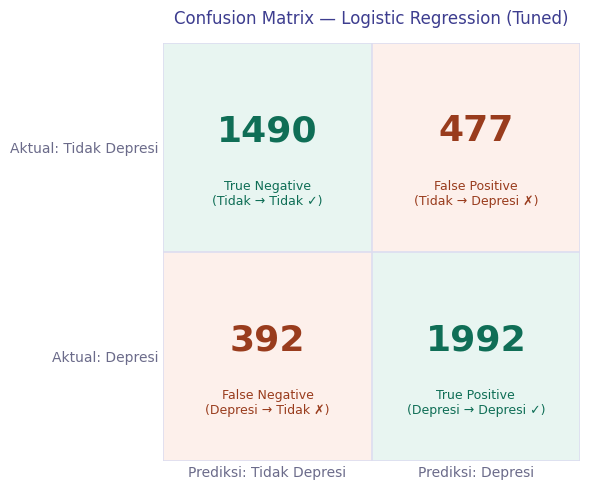

In [ ]:
# ══════════════════════════════════════════════════════════════
#  CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
cm     = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = [
    ["True Negative\n(Tidak → Tidak ✓)",  "False Positive\n(Tidak → Depresi ✗)"],
    ["False Negative\n(Depresi → Tidak ✗)", "True Positive\n(Depresi → Depresi ✓)"],
]
values = [[tn, fp], [fn, tp]]
colors = [["#E8F5F1", "#FDF0EB"], ["#FDF0EB", "#E8F5F1"]]
text_colors = [["#0F6E56", "#993C1D"], ["#993C1D", "#0F6E56"]]

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle(
            (j, 1 - i), 1, 1,
            color=colors[i][j], zorder=1
        ))
        ax.text(j + 0.5, 1 - i + 0.58,
                str(values[i][j]),
                ha="center", va="center",
                fontsize=26, fontweight="bold",
                color=text_colors[i][j], zorder=2)
        ax.text(j + 0.5, 1 - i + 0.28,
                labels[i][j],
                ha="center", va="center",
                fontsize=9, color=text_colors[i][j], zorder=2)

# grid lines
for x in [0, 1, 2]:
    ax.axvline(x, color="#DDDDF0", linewidth=1.2)
for y in [0, 1, 2]:
    ax.axhline(y, color="#DDDDF0", linewidth=1.2)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Prediksi: Tidak Depresi", "Prediksi: Depresi"],
                   fontsize=10, color="#6B6B8A")
ax.set_yticklabels(["Aktual: Depresi", "Aktual: Tidak Depresi"],
                   fontsize=10, color="#6B6B8A")
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Confusion Matrix — Logistic Regression (Tuned)",
             fontsize=12, color="#3D3D8F", pad=14, fontweight="medium")

plt.tight_layout()
plt.show()

In [ ]:
precision_vals, recall_vals, thresholds_vals = precision_recall_curve(y_test, y_prob)

# Threshold bawah → Recall ≥ 0.95 (ambil threshold tertinggi yang masih memenuhi)
mask_recall    = recall_vals[:-1] >= 0.95
thr_low        = thresholds_vals[mask_recall].max()
idx_low        = np.where(thresholds_vals == thr_low)[0][0]

# Threshold atas → Precision ≥ 0.90 (ambil threshold terendah yang sudah memenuhi)
mask_precision = precision_vals[:-1] >= 0.90
thr_high       = thresholds_vals[mask_precision].min()
idx_high       = np.where(thresholds_vals == thr_high)[0][0]

print(f"Threshold bawah (Recall ≥ 0.95)   : {thr_low:.4f} → Precision: {precision_vals[idx_low]:.4f} | Recall: {recall_vals[idx_low]:.4f}")
print(f"Threshold atas  (Precision ≥ 0.95) : {thr_high:.4f} → Precision: {precision_vals[idx_high]:.4f} | Recall: {recall_vals[idx_high]:.4f}")

Threshold bawah (Recall ≥ 0.95)   : 0.3365 → Precision: 0.7015 | Recall: 0.9501
Threshold atas  (Precision ≥ 0.95) : 0.7034 → Precision: 0.9000 | Recall: 0.5587


In [ ]:
# ── 1. PRECISION-RECALL CURVE (ambil semua data) ──────────────
precision_vals, recall_vals, thresholds_vals = precision_recall_curve(y_test, y_prob)

low = thr_low
high = thr_high

# Cari index threshold
idx_low  = np.argmin(np.abs(thresholds_vals - low))
idx_high = np.argmin(np.abs(thresholds_vals - high))

print(f"Threshold {low} → Precision: {precision_vals[idx_low]:.4f} | Recall: {recall_vals[idx_low]:.4f}")
print(f"Threshold {high} → Precision: {precision_vals[idx_high]:.4f} | Recall: {recall_vals[idx_high]:.4f}")
print(f"\nTotal titik kurva: {len(thresholds_vals)}")

# ── 2. DISTRIBUSI 3 KELAS (fix normalize) ─────────────────────
y_level = pd.cut(y_prob,
                 bins=[0, low, high, 1.0],
                 labels=["Rendah", "Sedang", "Tinggi"],
                 include_lowest=True)

counts = y_level.value_counts()
pct    = (counts / counts.sum() * 100).round(1)

print("\nDistribusi Kelas Risiko:")
for label in ["Rendah", "Sedang", "Tinggi"]:
    print(f"  {label:8s}: {counts[label]:4d} sampel ({pct[label]}%)")

Threshold 0.3365175408169001 → Precision: 0.7015 | Recall: 0.9501
Threshold 0.703362028219295 → Precision: 0.9000 | Recall: 0.5587

Total titik kurva: 4350

Distribusi Kelas Risiko:
  Rendah  : 1123 sampel (25.8%)
  Sedang  : 1749 sampel (40.2%)
  Tinggi  : 1479 sampel (34.0%)


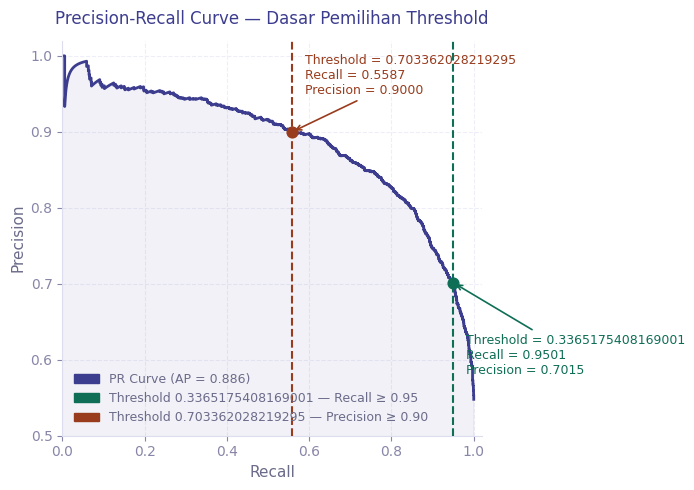

Tersimpan: precision_recall_curve.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

FONT = 'DejaVu Sans'

precision_vals, recall_vals, thresholds_vals = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)


idx_low  = np.argmin(np.abs(thresholds_vals - thr_low))
idx_high = np.argmin(np.abs(thresholds_vals - thr_high))

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(recall_vals, precision_vals,
        color='#3D3D8F', linewidth=2)
ax.fill_between(recall_vals, precision_vals,
                alpha=0.07, color='#3D3D8F')

ax.axvline(x=recall_vals[idx_low], color='#0F6E56',
           linestyle='--', linewidth=1.5, zorder=3)
ax.scatter(recall_vals[idx_low], precision_vals[idx_low],
           color='#0F6E56', s=60, zorder=5)
ax.annotate(f'Threshold = {thr_low}\nRecall = {recall_vals[idx_low]:.4f}\nPrecision = {precision_vals[idx_low]:.4f}',
            xy=(recall_vals[idx_low], precision_vals[idx_low]),
            xytext=(recall_vals[idx_low] + 0.03, precision_vals[idx_low] - 0.12),
            fontsize=9, color='#0F6E56', fontfamily=FONT,
            arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2))

ax.axvline(x=recall_vals[idx_high], color='#993C1D',
           linestyle='--', linewidth=1.5, zorder=3)
ax.scatter(recall_vals[idx_high], precision_vals[idx_high],
           color='#993C1D', s=60, zorder=5)
ax.annotate(f'Threshold = {thr_high}\nRecall = {recall_vals[idx_high]:.4f}\nPrecision = {precision_vals[idx_high]:.4f}',
            xy=(recall_vals[idx_high], precision_vals[idx_high]),
            xytext=(recall_vals[idx_high] + 0.03, precision_vals[idx_high] + 0.05),
            fontsize=9, color='#993C1D', fontfamily=FONT,
            arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1.2))

ax.set_xlabel('Recall', fontsize=11, color='#6B6B8A', fontfamily=FONT)
ax.set_ylabel('Precision', fontsize=11, color='#6B6B8A', fontfamily=FONT)
ax.set_xlim(0, 1.02)
ax.set_ylim(0.5, 1.02)
ax.tick_params(colors='#8886A8', labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))

ax.yaxis.grid(True, color='#EEEEF8', linestyle='--', linewidth=0.8, zorder=0)
ax.xaxis.grid(True, color='#EEEEF8', linestyle='--', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#DDDDF0')

patches = [
    mpatches.Patch(color='#3D3D8F', label=f'PR Curve (AP = {ap:.3f})'),
    mpatches.Patch(color='#0F6E56', label=f'Threshold {thr_low} — Recall ≥ 0.95'),
    mpatches.Patch(color='#993C1D', label=f'Threshold {thr_high} — Precision ≥ 0.90'),
]
ax.legend(handles=patches, loc='lower left', fontsize=9,
          frameon=False, labelcolor='#6B6B8A')

ax.set_title('Precision-Recall Curve — Dasar Pemilihan Threshold',
             fontsize=12, color='#3D3D8F', pad=12, fontfamily=FONT)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: precision_recall_curve.png")

Feature Importances:
                         Feature  Coefficient
               Academic Pressure       0.7772
                Financial Stress       0.5179
                             Age      -0.2498
                  Dietary Habits      -0.2388
                Work/Study Hours       0.2384
              Study Satisfaction      -0.1718
                  Sleep Duration      -0.0846
                            City       0.0189
Family History of Mental Illness       0.0021
                 Education Level       0.0000
                          Gender       0.0000
                            CGPA       0.0000


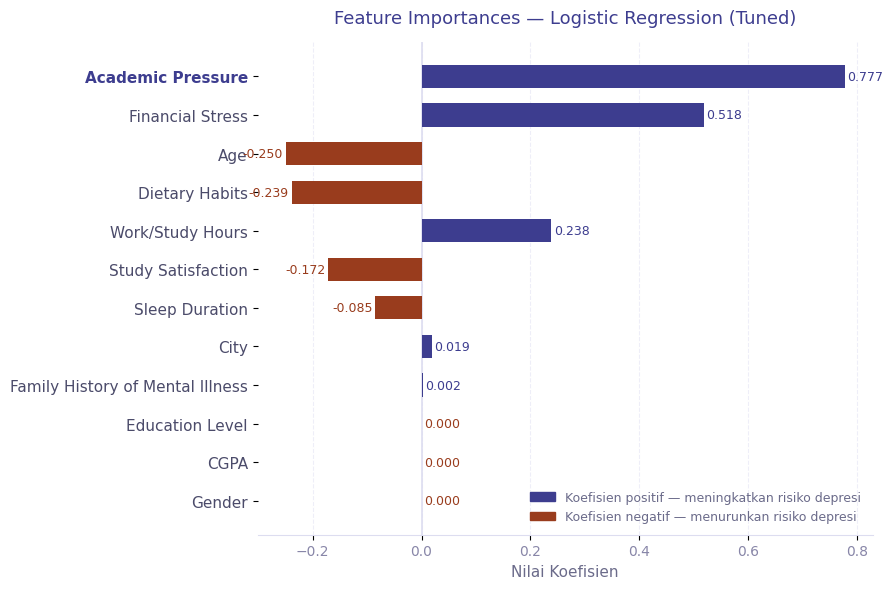

In [ ]:
FONT = 'DejaVu Sans'

# ── DATA ──────────────────────────────────────────────────────
feature_names = X_train.columns.tolist()
coefficients  = best_pipe.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=np.abs, ascending=True)  # ascending=True agar bar terbesar di atas

print("Feature Importances:")
print(coef_df.sort_values('Coefficient', key=np.abs, ascending=False).round(4).to_string(index=False))

# ── PLOT ──────────────────────────────────────────────────────
features = coef_df['Feature'].tolist()
values   = coef_df['Coefficient'].tolist()
y        = np.arange(len(features))
bar_colors = ['#3D3D8F' if v > 0 else '#993C1D' for v in values]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(y, values, color=bar_colors, height=0.6, zorder=3, linewidth=0)

for bar, val, color in zip(bars, values, bar_colors):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha,
            fontsize=9, color=color, fontfamily=FONT)

ax.axvline(0, color='#DDDDF0', linewidth=1.2, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(features, fontsize=11, fontfamily=FONT, color='#4B4B6A')

# Highlight fitur terbesar
max_idx = coef_df['Coefficient'].abs().values.argmax()
ax.get_yticklabels()[max_idx].set_color('#3D3D8F')
ax.get_yticklabels()[max_idx].set_fontweight('bold')

ax.xaxis.set_tick_params(labelcolor='#8886A8', labelsize=10)
ax.xaxis.grid(True, color='#EEEEF8', linestyle='--', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#DDDDF0')

patches = [
    mpatches.Patch(color='#3D3D8F', label='Koefisien positif — meningkatkan risiko depresi'),
    mpatches.Patch(color='#993C1D', label='Koefisien negatif — menurunkan risiko depresi'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9,
          frameon=False, labelcolor='#6B6B8A')

ax.set_title('Feature Importances — Logistic Regression (Tuned)',
             fontsize=13, color='#3D3D8F', pad=14,
             fontfamily=FONT, fontweight='medium')
ax.set_xlabel('Nilai Koefisien', fontsize=11, color='#6B6B8A', fontfamily=FONT)

plt.tight_layout()
plt.show()


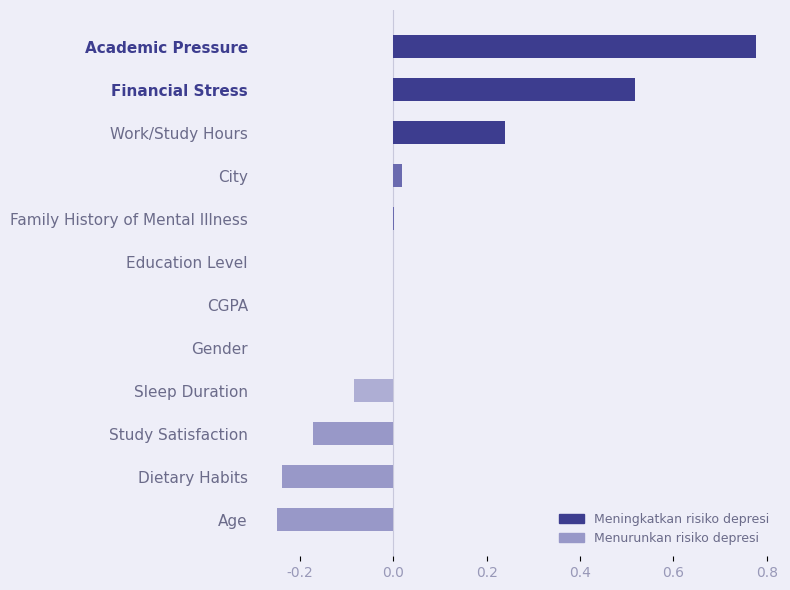

Tersimpan: feature_importances.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FONT = 'DejaVu Sans'

# ── DATA ──────────────────────────────────────────────────────
feature_names = X_train.columns.tolist()
coefficients  = best_pipe.named_steps['model'].coef_[0]

import pandas as pd
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

features = coef_df['Feature'].tolist()
values   = coef_df['Coefficient'].tolist()
y        = np.arange(len(features))

# Warna berbasis intensitas
def pick_color(v):
    if   v >  0.1: return '#3D3D8F'
    elif v >  0:   return '#6A6AAF'
    elif v == 0:   return '#CBCAE0'
    elif v > -0.1: return '#AEAED4'
    else:          return '#9898C8'

bar_colors = [pick_color(v) for v in values]

# ── PLOT ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#EEEEF8')
ax.set_facecolor('#EEEEF8')

ax.barh(y, values, color=bar_colors, height=0.55,
        zorder=3, linewidth=0)

# Garis nol
ax.axvline(0, color='#C8C8DC', linewidth=0.8, zorder=2)

# ── AXIS ──────────────────────────────────────────────────────
ax.set_yticks(y)
ax.set_yticklabels(features, fontsize=11, fontfamily=FONT)
for i, label in enumerate(ax.get_yticklabels()):
    label.set_color('#3D3D8F' if abs(values[i]) >= 0.5 else '#6B6B8A')
    if abs(values[i]) >= 0.5:
        label.set_fontweight('bold')

ax.xaxis.set_tick_params(labelcolor='#9898B8', labelsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))

# ── GRID & SPINES ─────────────────────────────────────────────
ax.xaxis.grid(False)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='y', length=0)

# ── LEGEND ────────────────────────────────────────────────────
from matplotlib.patches import Patch
patches = [
    Patch(color='#3D3D8F', label='Meningkatkan risiko depresi'),
    Patch(color='#9898C8', label='Menurunkan risiko depresi'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9,
          frameon=False, labelcolor='#6B6B8A')


plt.tight_layout()
plt.savefig('feature_importances.png', dpi=200,
            bbox_inches='tight', facecolor='#EEEEF8')
plt.show()
print("Tersimpan: feature_importances.png")

In [ ]:
import pickle

# Pastikan pipeline sudah di-fit sebelumnya
# pipeline.fit(X_train, y_train)

# 1. Ambil dan simpan Target Encoder
target_encoder = best_pipe.named_steps['te']
with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)

# 3. Ambil dan simpan Standard Scaler
scaler = best_pipe.named_steps['scaler']
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 4. Ambil dan simpan Model Logistic Regression
model = best_pipe.named_steps['model']
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Semua komponen berhasil disimpan secara terpisah!")

Semua komponen berhasil disimpan secara terpisah!


In [ ]:
import pickle
FEATURE_COLS = [
    'Gender',
    'Age',
    'City',
    'Academic Pressure',
    'CGPA',
    'Study Satisfaction',
    'Sleep Duration',
    'Dietary Habits',
    'Education Level',
    'Work/Study Hours',
    'Financial Stress',
    'Family History of Mental Illness',
]


with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Scaler order :", list(scaler.feature_names_in_))
print("FEATURE_COLS :", FEATURE_COLS)
print("Match        :", list(scaler.feature_names_in_) == FEATURE_COLS)

Scaler order : ['Gender', 'Age', 'City', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Education Level', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
FEATURE_COLS : ['Gender', 'Age', 'City', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Education Level', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Match        : True


In [ ]:
with open("target_encoder.pkl", "rb") as f:
    te = pickle.load(f)

print(type(te))               # tipe encoder-nya apa
print(dir(te))                # atribut yang tersedia
print(te.__dict__)            # isi lengkap objek

<class 'category_encoders.target_encoder.TargetEncoder'>
['INVARIANCE_THRESHOLD', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_check_dict_key_tuples', '_check_feature_names', '_check_fit_inputs', '_check_n_features', '_check_transform_inputs', '_determine_fit_columns', '_dim', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_drop_invariants', '_fit', '_generate_inverted_hierarchy', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_mean', '_more_tags', '_repr_html_', '_repr_